### Importing Libraries

In [102]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

## Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | [Problem Framing](#1-problem-framing) | Survival analysis setup, censoring, metric breakdown |
| 2 | [Setup & Config](#2-setup--config) | Hyperparameters, seeds, run modes |
| 3 | [Install & Imports](#3-install--imports) | scikit-survival, LightGBM, dependencies |
| 4 | [Exploratory Data Analysis](#4-exploratory-data-analysis) | Distance, time-to-hit, correlations, the 5 km rule |
| 5 | [Feature Engineering](#5-feature-engineering) | Distance transforms, kinematics, threat scores |
| 6 | [Metric Implementation](#6-metric-implementation) | C-index, Brier score, IPCW, hybrid score |
| 7 | [GBSA Survival Ensemble](#7-gbsa-survival-ensemble) | Multi-config, multi-seed gradient boosting survival |
| 8 | [LightGBM IPCW Classifiers](#8-lightgbm-ipcw-classifiers) | Per-horizon classifiers with censoring-corrected weights |
| 9 | [Ensemble Blending](#9-ensemble-blending) | Rank-normalization, fixed weights, monotonicity enforcement |
| 10 | [OOF Validation](#10-oof-validation) | Out-of-fold hybrid score, Brier per horizon |
| 11 | [Submission](#11-submission) | Generate & validate final predictions |
| 12 | [Lessons Learned](#12-lessons-learned) | Overfitting traps, do's and don'ts |

In [103]:
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')
metaData = pd.read_csv('Data/metaData.csv')

train = pd.DataFrame(train)
test = pd.DataFrame(test)
metaData = pd.DataFrame(metaData)

feat = [col for col in train.columns if col not in ['event_id', 'time_to_hit_hours', 'event']]
X_train = train[feat].copy()
X_test = test[feat].copy()
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_test.median(numeric_only=True))

### Exploratory data analysis

In [104]:
train.shape

(221, 37)

In [105]:
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,0.000000,0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,0.000000,0.000000,21,5,7,44.990274,0


In [106]:
def draw_kde_plot(df, dict_category, width=20, height=4):
    for category, col_list in dict_category.items():
        valid_cols = [col for col in col_list if col in df.columns]
        
        if not valid_cols:
            continue

        n_cols = width
        n_plots = len(valid_cols)
        n_rows = math.ceil(n_plots / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, height * n_rows))
        fig.suptitle(f"KDE plot for category: {category}", fontsize=17, fontweight="bold", y=1.02)

        if n_plots == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        for i, col in enumerate(valid_cols):
            sns.kdeplot(data=df, x=col, ax=axes[i])
            axes[i].set_title(f"KDE of {col}")
            axes[i].set_xlabel(col)

        for j in range(n_plots, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
            

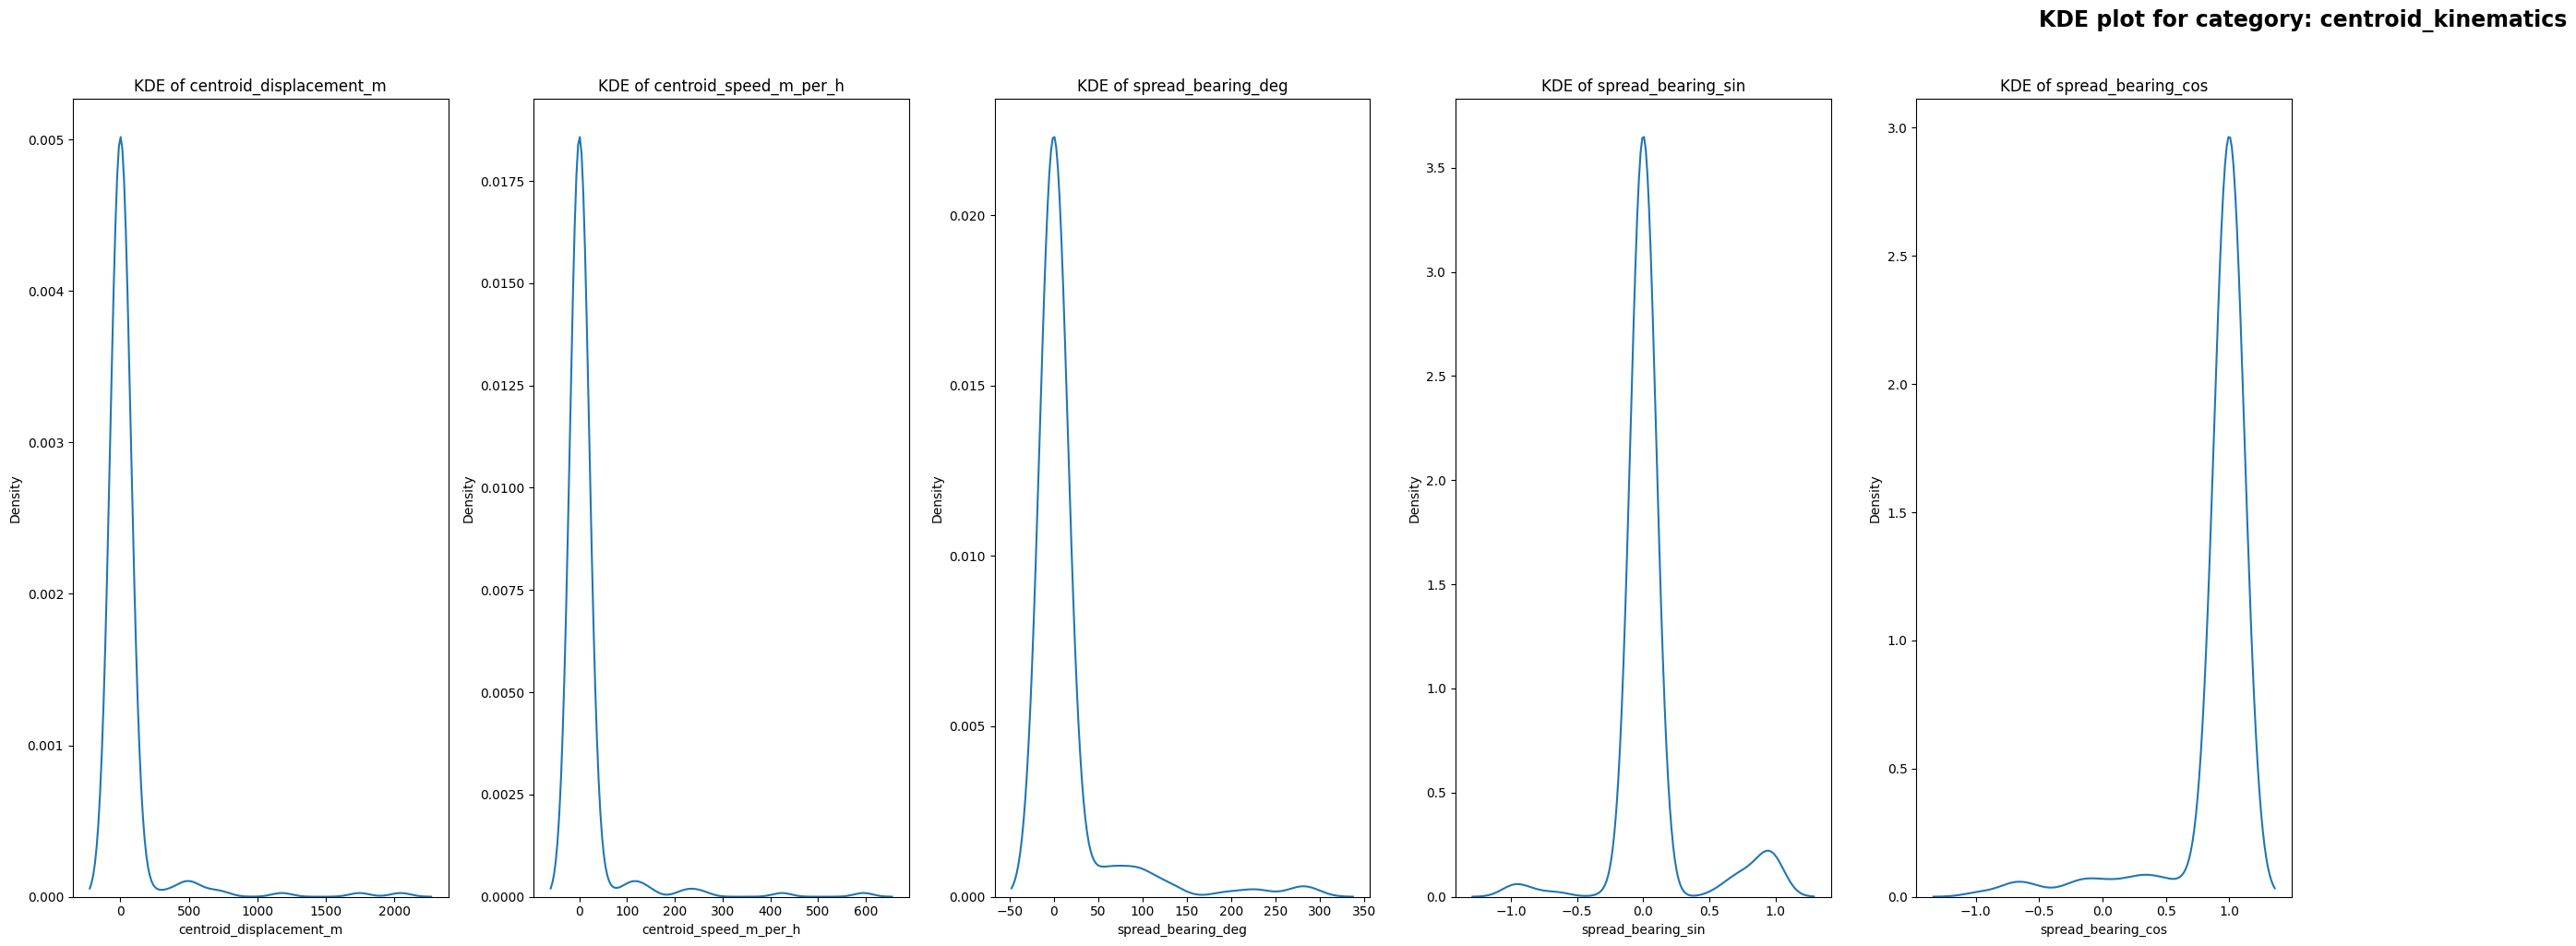

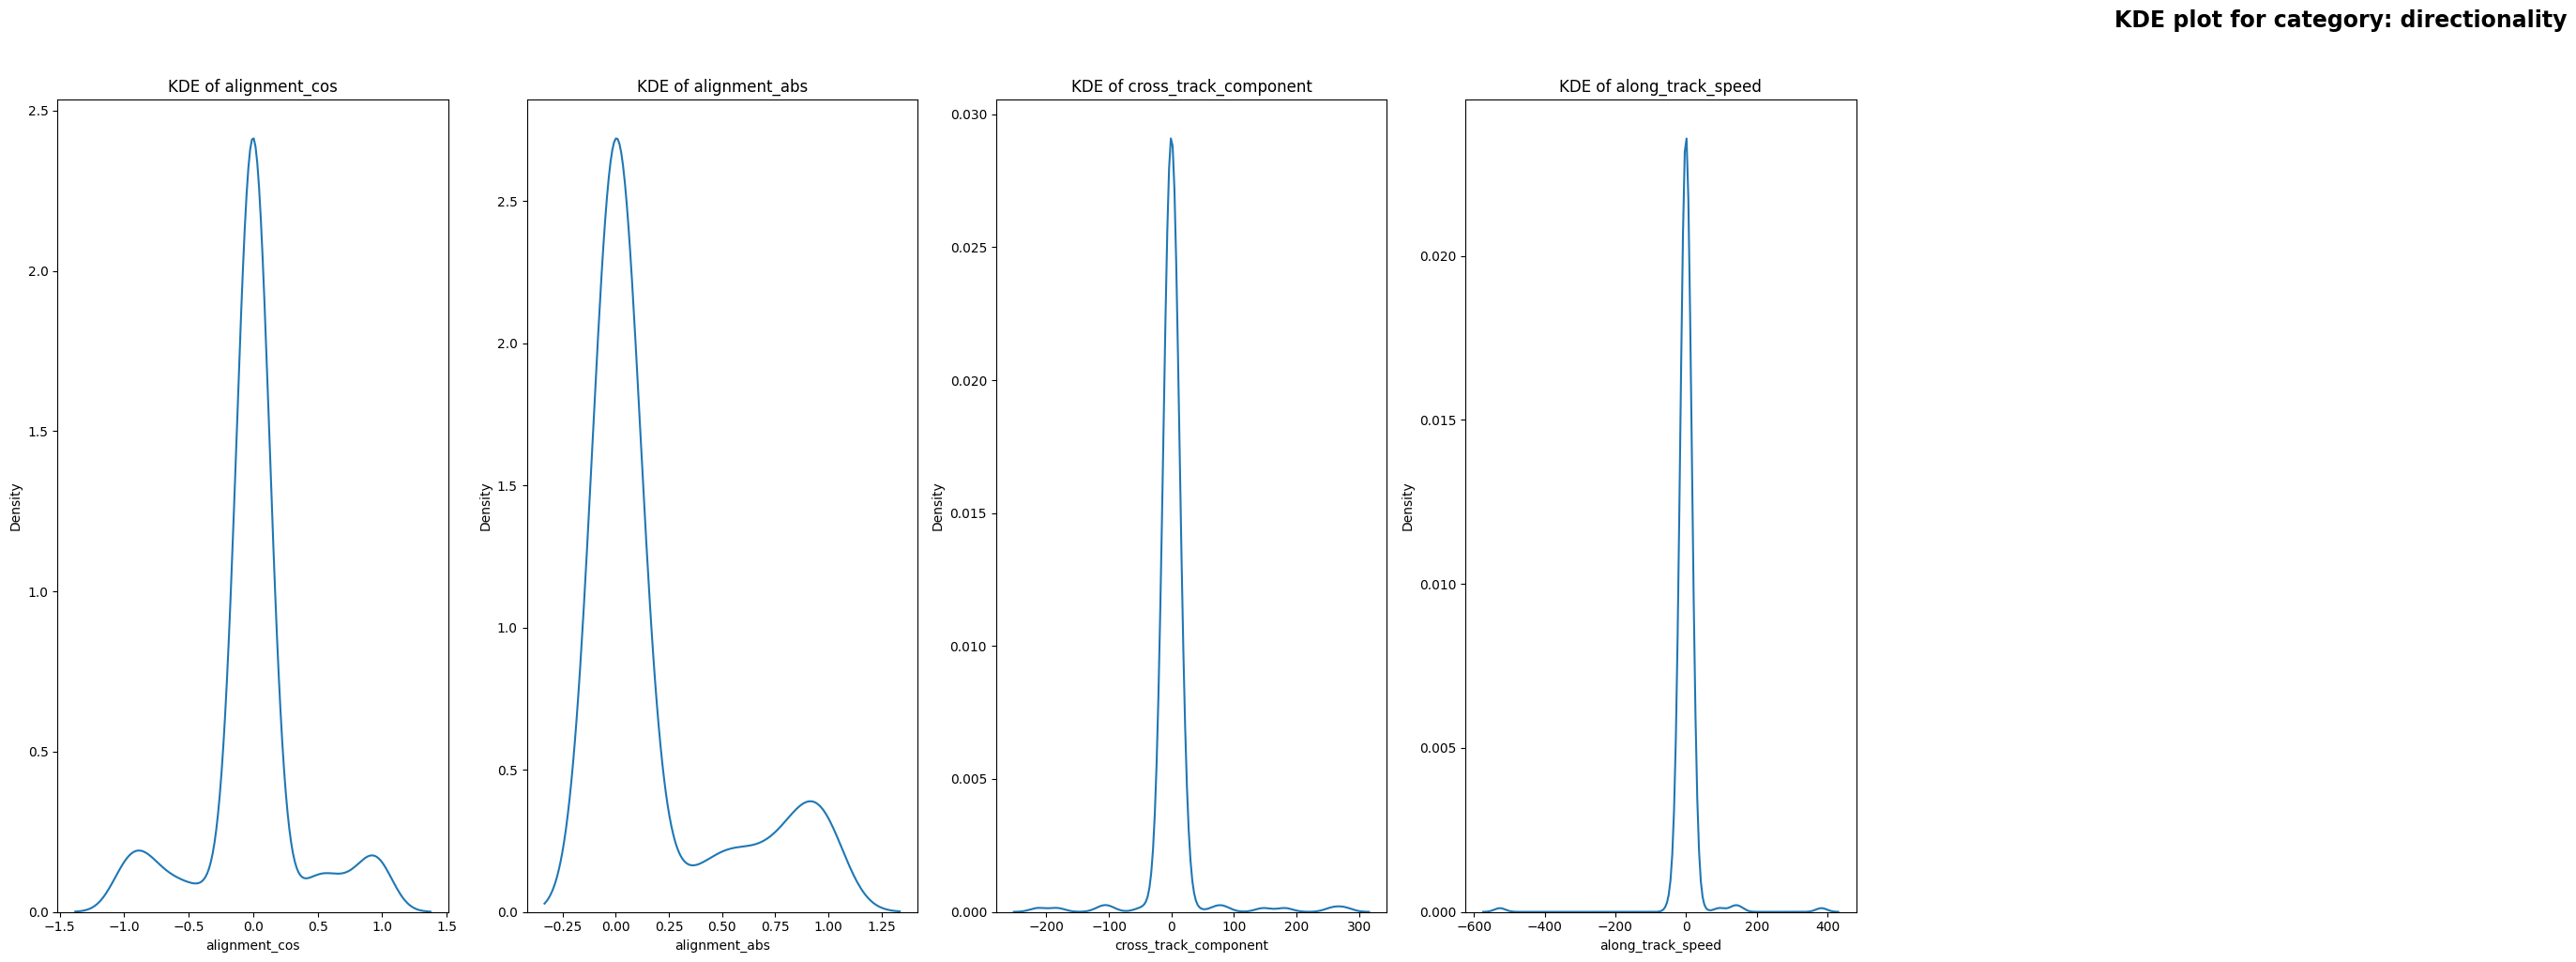

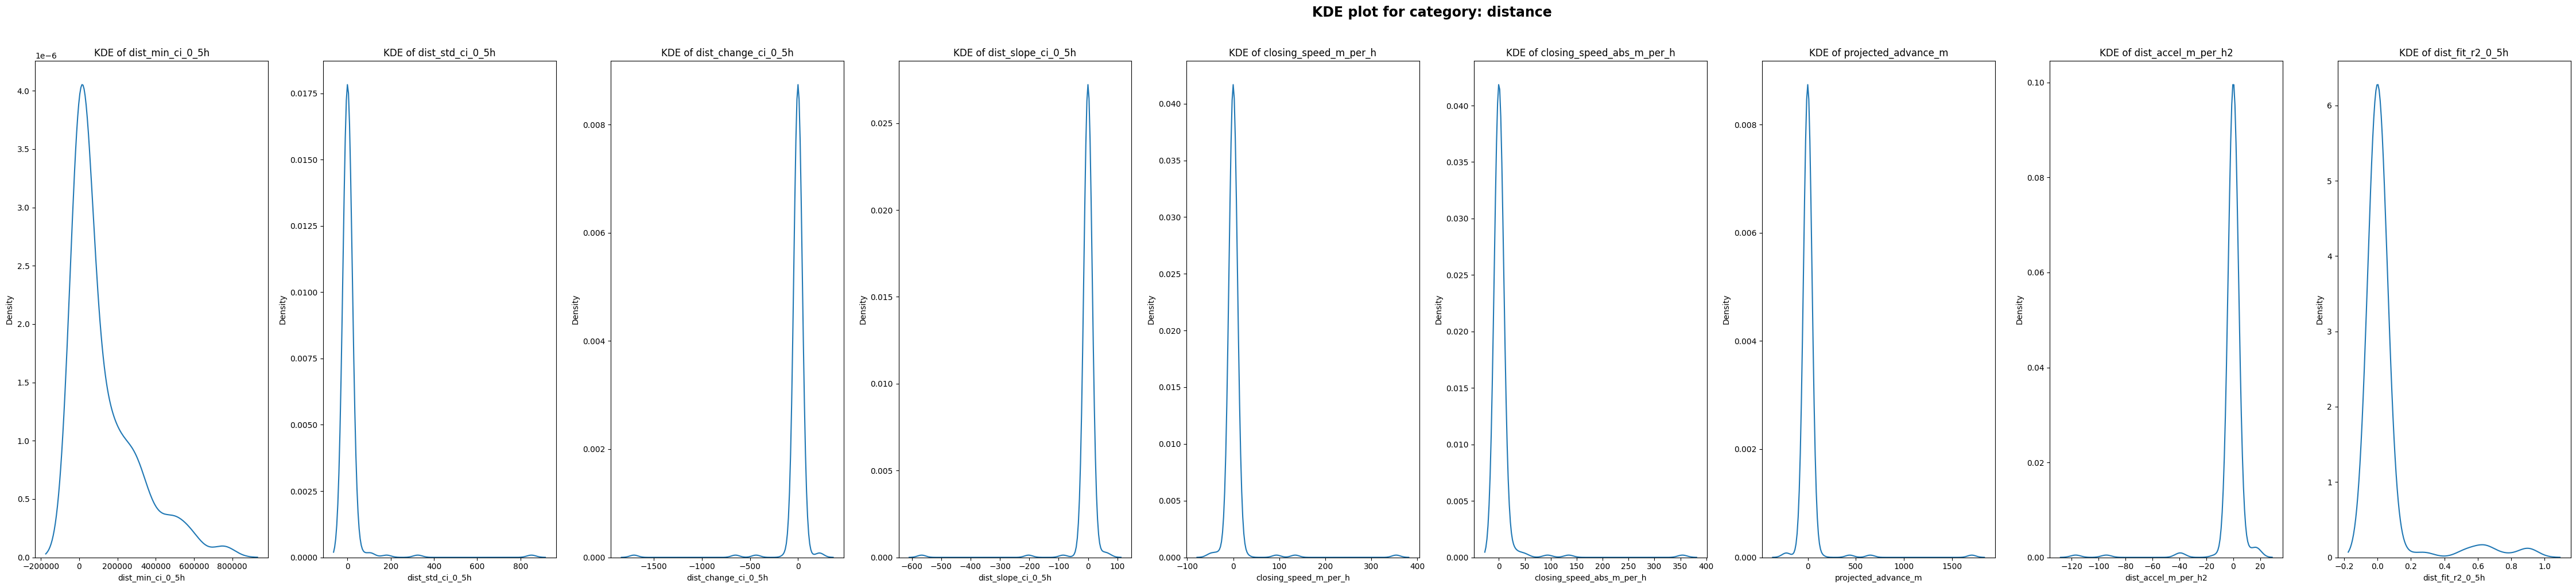

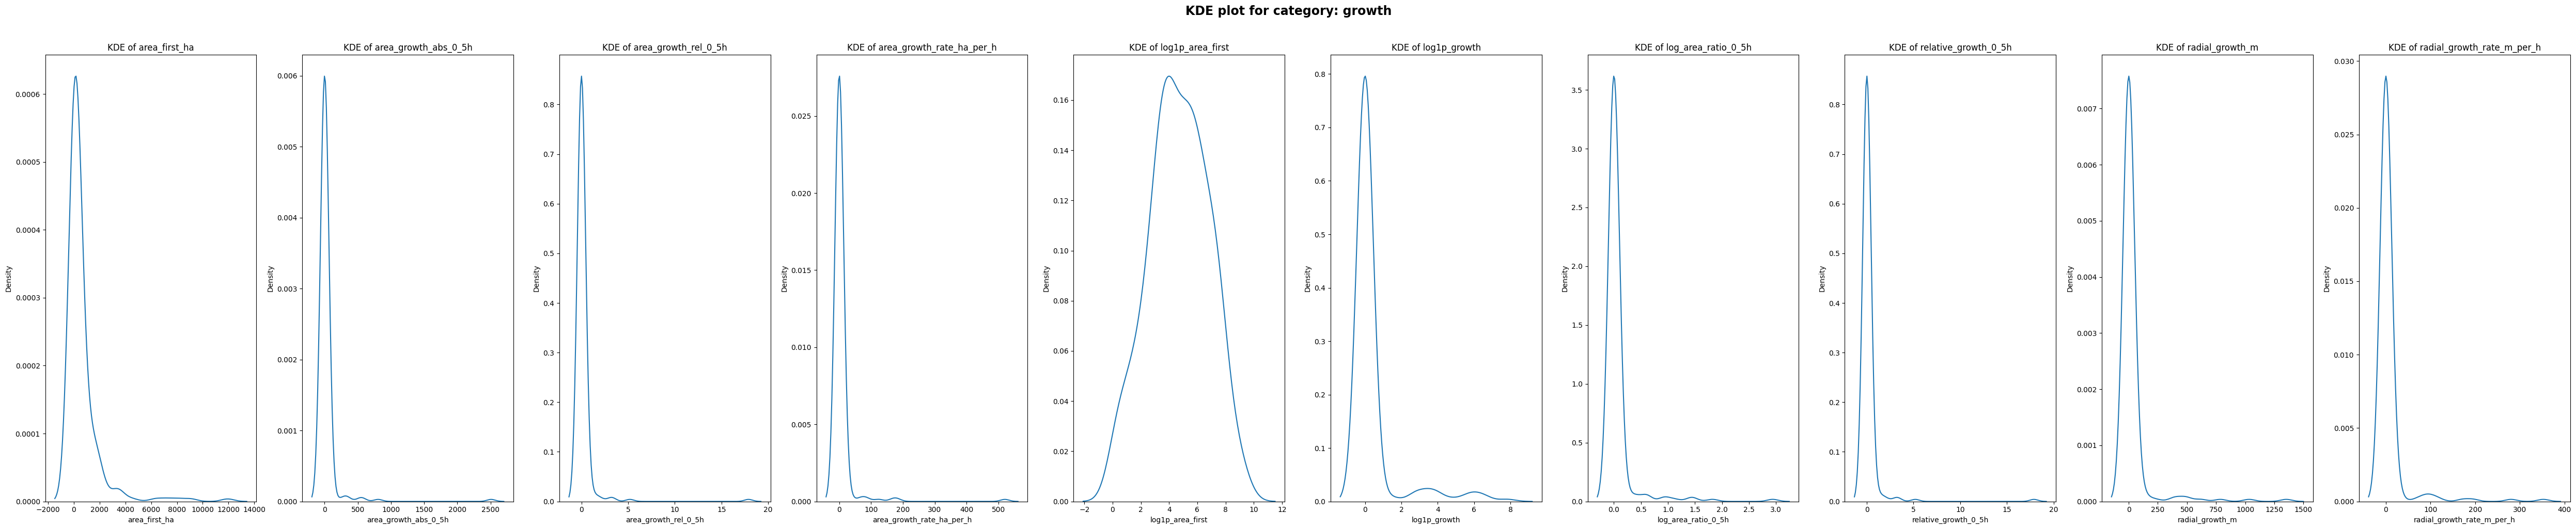

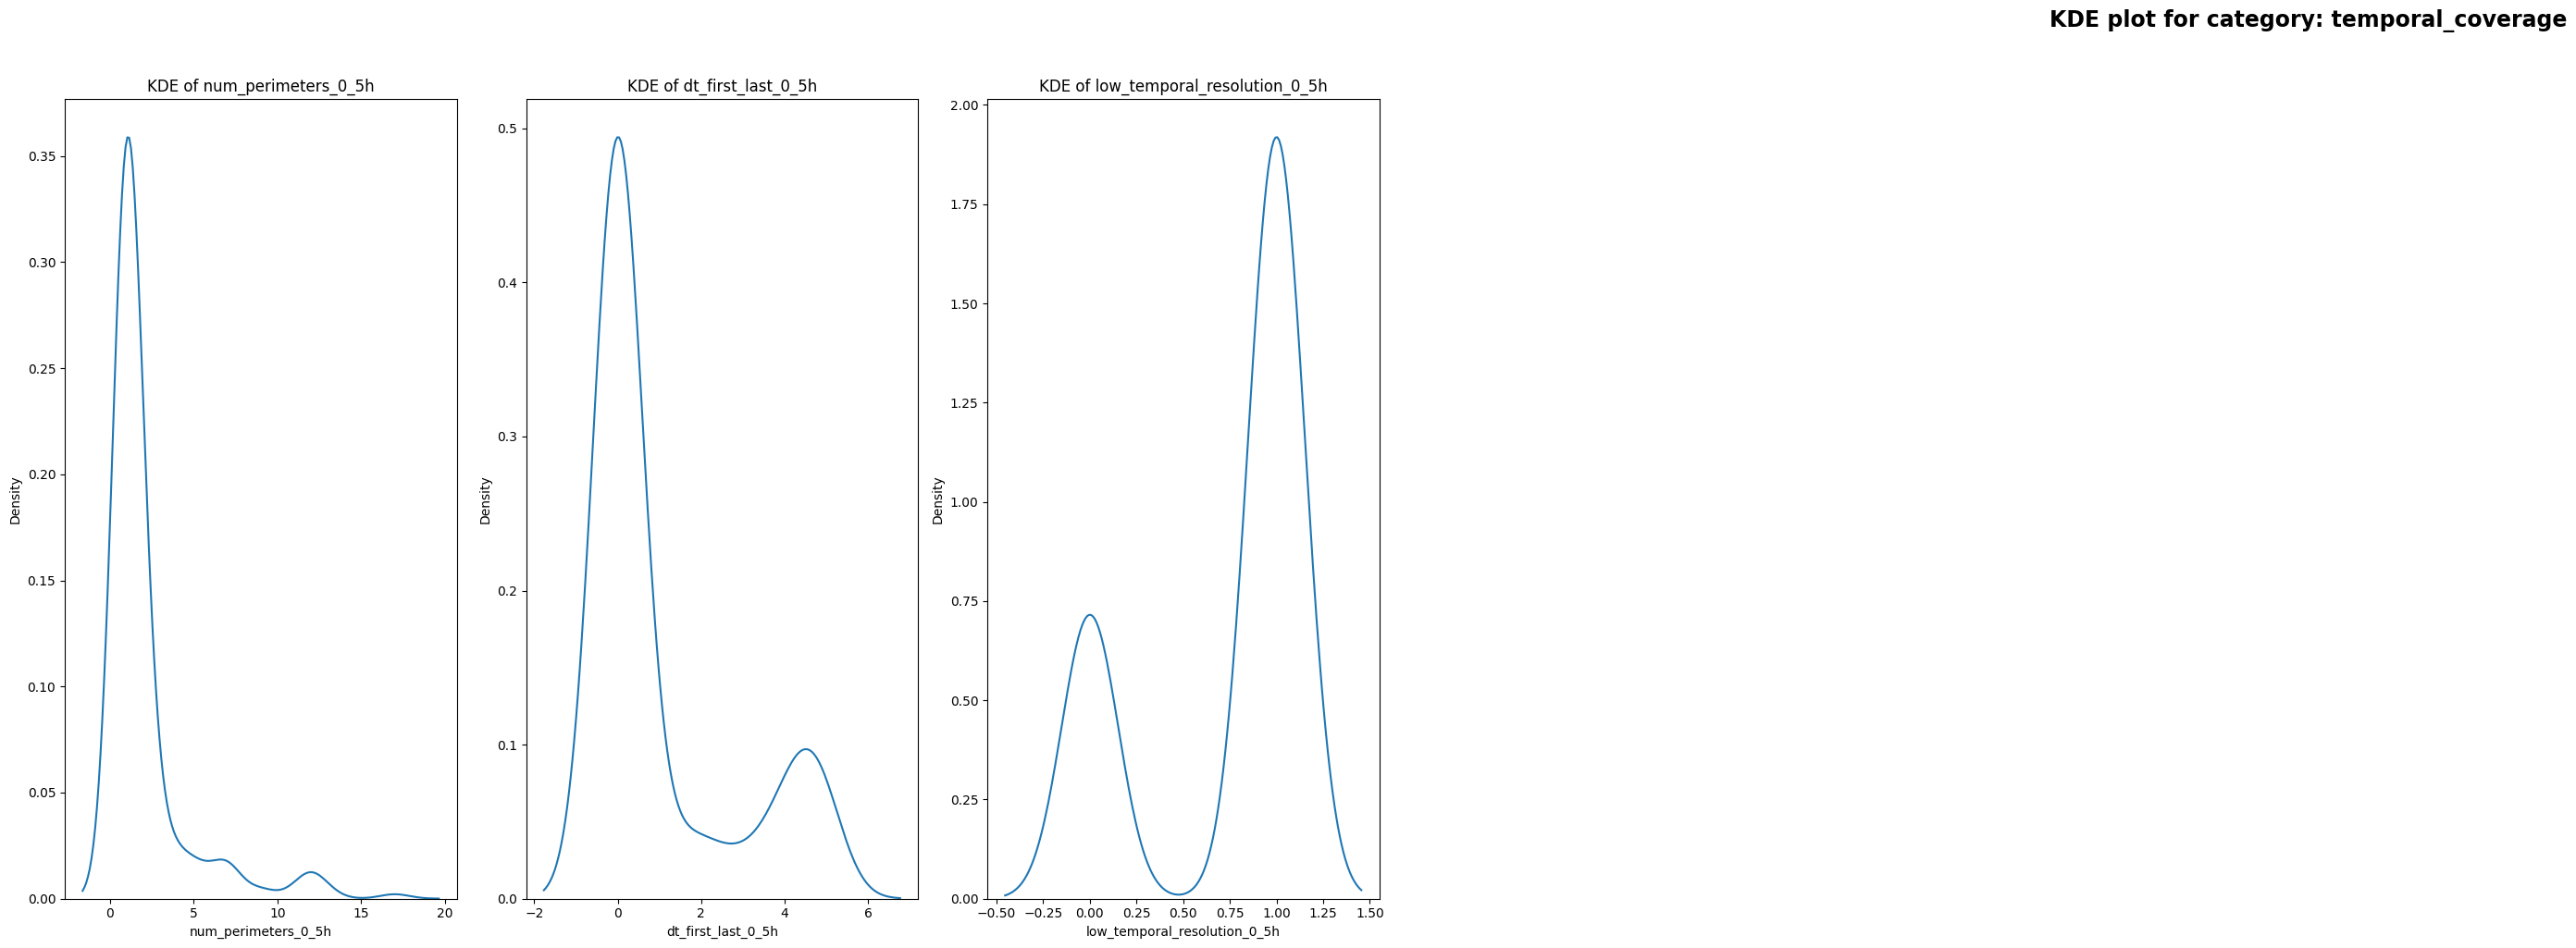

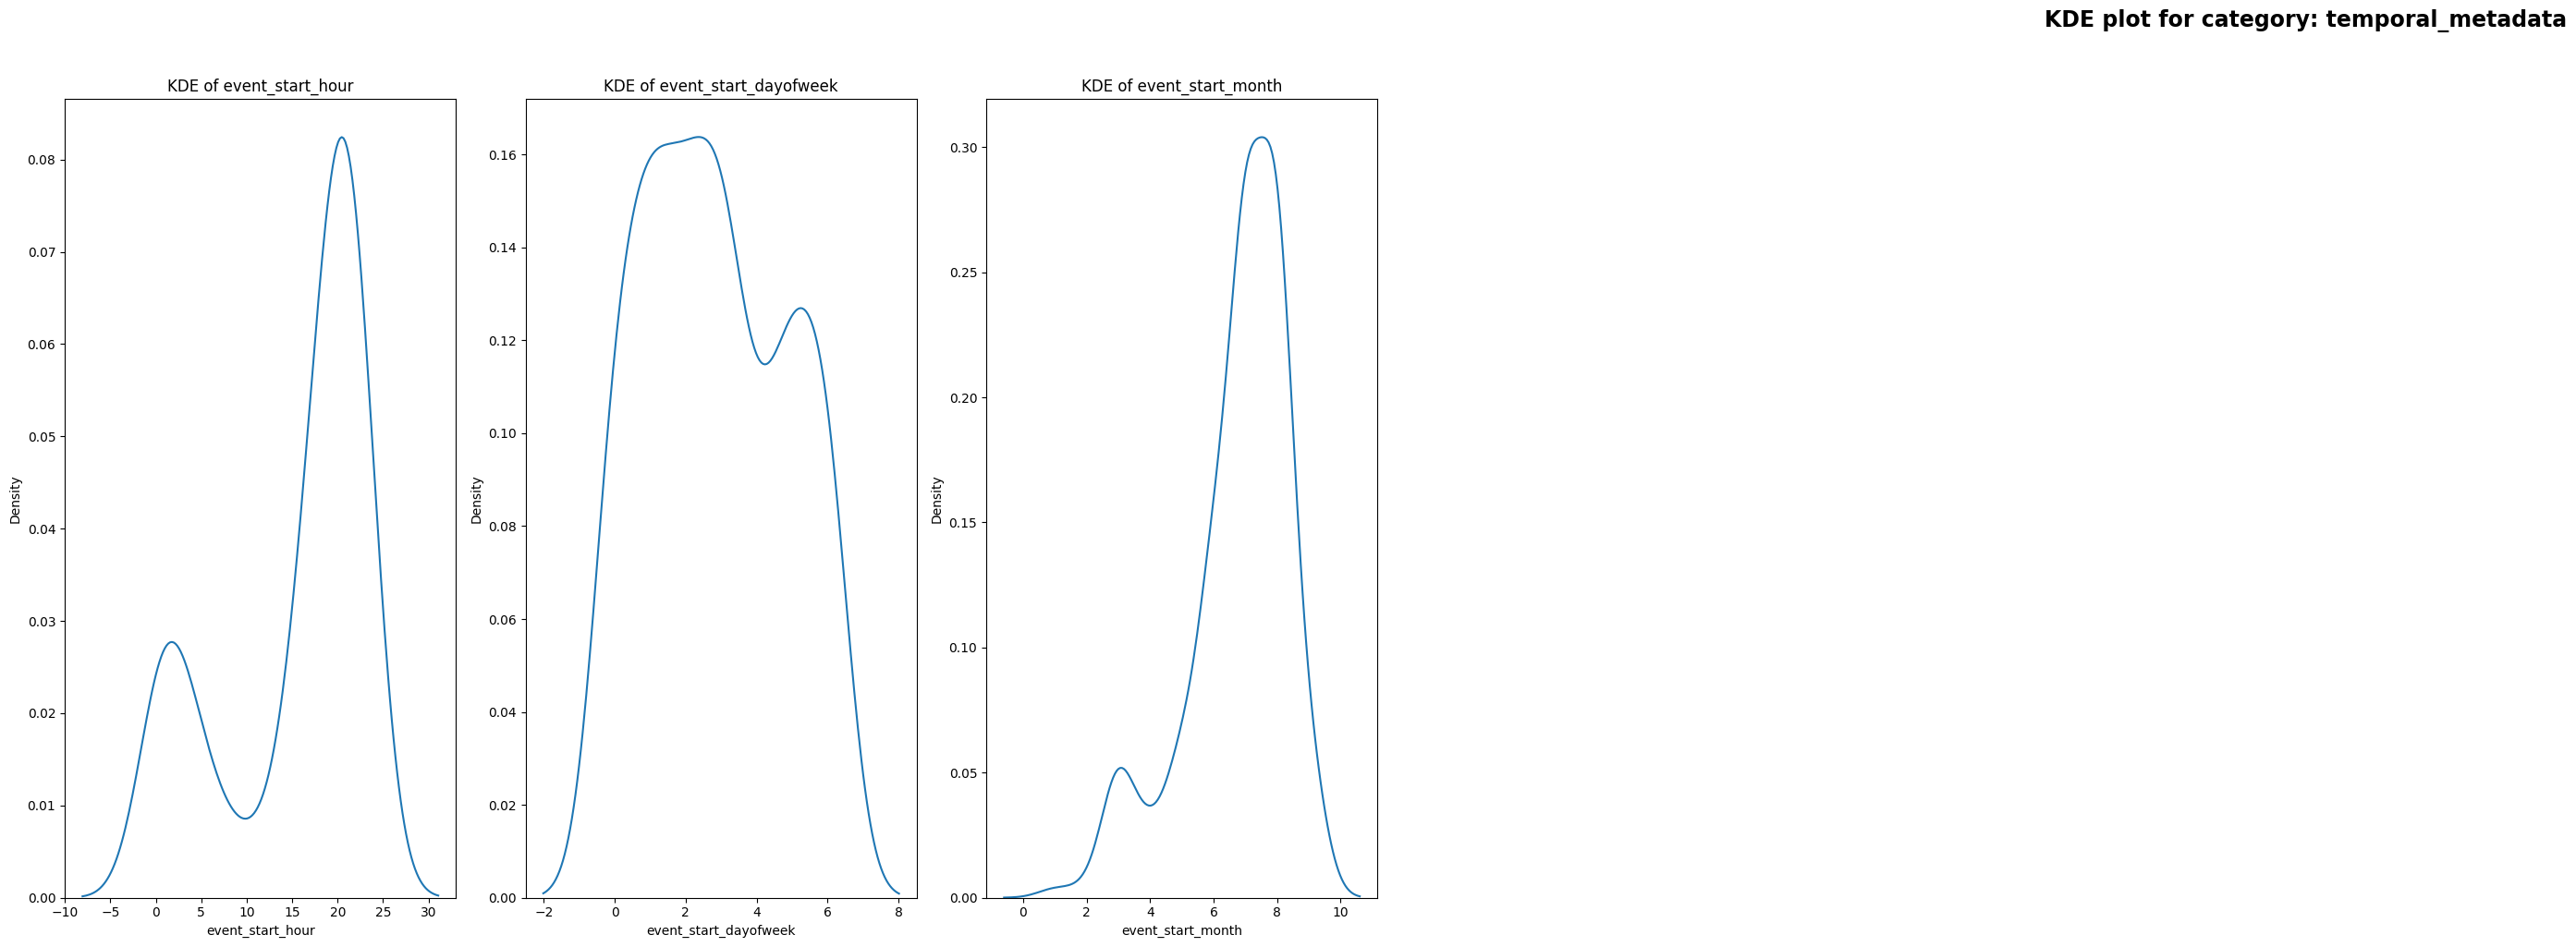

In [107]:
X_train_copy = X_train.copy()
dict_categories_columns = {}
for category, group in metaData.groupby("category"):
    dict_categories_columns[category] = group["column"].tolist()
draw_kde_plot(X_train_copy, dict_categories_columns, width=10, height=10)

### Feature Engineering

In [108]:
def feat_engineering() -> pd.DataFrame:
    pass


In [109]:
event_col = train['event']
time_to_hit_col = train['time_to_hit_hours']

y_12 = ((event_col == 1) & (time_to_hit_col <= 12)).astype(int)
y_24 = ((event_col == 1) & (time_to_hit_col <= 24)).astype(int)
y_48 = ((event_col == 1) & (time_to_hit_col <= 48)).astype(int)
y_72 = ((event_col == 1) & (time_to_hit_col <= 72)).astype(int)

targets = {
    "12": y_12,
    "24": y_24,
    "48": y_48,
    "72": y_72
}



In [110]:
#Train one classifier for each time horizon, then store the predicted probability of class 1 on the test set.
preds = {}
randomForest_clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=8,
        random_state=42,
        class_weight="balanced"
    )
for horizon, y in targets.items():
    randomForest_clf.fit(X_train, y)
    preds[horizon] = randomForest_clf.predict_proba(X_test)[:, 1]

In [111]:
p12 = preds["12"]
p24 = np.maximum(preds["24"], p12)
p48 = np.maximum(preds["48"], p24)
p72 = np.maximum(preds["72"], p48)

randomForest = pd.DataFrame({
    "event_id": test["event_id"],
    "prob_12h": p12,
    "prob_24h": p24,
    "prob_48h": p48,
    "prob_72h": p72
})
randomForest

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.182475,0.200847,0.200847,0.227711
1,13353600,0.522476,0.696377,0.696377,0.696377
2,13942327,0.127345,0.148916,0.172369,0.199872
3,16112781,0.597776,0.714711,0.715819,0.724276
4,17132808,0.715011,0.715011,0.715011,0.715011
...,...,...,...,...,...
90,94627327,0.405366,0.405366,0.433706,0.433706
91,96570675,0.133340,0.177232,0.177232,0.178494
92,97225766,0.160057,0.242741,0.246942,0.248483
93,98446281,0.371064,0.375217,0.377341,0.377447


In [112]:
preds = {}

lightGBM_clf = LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='binary_logloss',
    learning_rate=0.01,
    max_depth=4,
)

for horizon, y in targets.items():
    lightGBM_clf.fit(X_train, y)
    preds[horizon] = lightGBM_clf.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 49, number of negative: 172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 474
[LightGBM] [Info] Number of data points in the train set: 221, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221719 -> initscore=-1.255674
[LightGBM] [Info] Start training from score -1.255674
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [113]:
p12 = preds["12"]
p24 = np.maximum(preds["24"], p12)
p48 = np.maximum(preds["48"], p24)
p72 = np.maximum(preds["72"], p48)

lightGBM = pd.DataFrame({
    "event_id": test["event_id"],
    "prob_12h": p12,
    "prob_24h": p24,
    "prob_48h": p48,
    "prob_72h": p72
})
lightGBM
lightGBM.to_csv('submission.csv', index=False)
